# View Ray Tracer Output

Load and display ray tracer images — either PGM (P5 binary) files or the
`"image"` array embedded in HDF5 field snapshots.

Set `DATA_ROOT` below to point to your ray tracer output directory.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
import re

In [7]:
# ============================================================
#  Path setup — same pattern as AJ_analysis
# ============================================================
# The ray tracer writes into output_dir (default "Data/") under
# the Aperture4 root.  Adjust this to point at your run directory.
DATA_ROOT = Path(
    "/data/RIS/cyuran/Active/giantflares/Aaron/Aperture4"
)

# ============================================================
#  PGM (P5 binary) helpers
# ============================================================
def read_pgm_p5(filepath):
    """Read a P5 (binary) PGM file → (width, height, maxval, pixels)."""
    with open(filepath, "rb") as f:
        header = f.readline().strip()
        if header != b"P5":
            raise ValueError(f"Not a P5 PGM file: {header}")
        line = f.readline()
        while line.startswith(b"#"):
            line = f.readline()
        width, height = map(int, line.split())
        maxval = int(f.readline().strip())
        dtype = np.uint8 if maxval < 256 else np.uint16
        pixels = np.frombuffer(f.read(), dtype=dtype)
        return width, height, maxval, pixels.reshape((height, width))


def find_pgm_files(data_dir, pattern="rt_image_*.pgm"):
    """Glob PGM files, sorted by embedded step number."""
    data_dir = Path(data_dir)
    return sorted(
        data_dir.glob(pattern),
        key=lambda p: int(re.search(r"(\d+)", p.stem).group()),
    )


# ============================================================
#  HDF5 snapshot helper — "image" is saved with field data
# ============================================================
def get_image_h5(filepath, dataset_name="image", base_dir=DATA_ROOT):
    """
    Read the 2-D ``image`` array from an HDF5 field snapshot.

    Parameters
    ----------
    filepath : str or Path
        Relative or absolute path, e.g. ``"Data/fld.00005.h5"``.
    dataset_name : str
        Dataset name inside the HDF5 file (default ``"image"``).
    base_dir : Path
        Prepended when *filepath* is relative.
    """
    base_dir = Path(base_dir)
    filepath = Path(filepath)
    resolved = filepath if filepath.is_absolute() else base_dir / filepath

    with h5py.File(resolved, "r") as f:
        if dataset_name not in f:
            available = sorted(f.keys())
            raise KeyError(
                f"'{dataset_name}' not found in {resolved.name}. "
                f"Available: {available}"
            )
        img = np.asarray(f[dataset_name])
        # HDF5 data is (y, x) from Fortran-ordered write; transpose to (x, y)
        print(f"✓ '{dataset_name}' from {resolved.name}  shape={img.shape}")
        return img.T


def find_image_h5(data_dir, pattern="fld.*.h5", dataset_name="image"):
    """Find HDF5 field snapshots that contain ``dataset_name``."""
    data_dir = Path(data_dir)
    files = sorted(
        data_dir.glob(pattern),
        key=lambda p: int(re.search(r"(\d+)", p.stem).group()),
    )
    valid = []
    for p in files:
        try:
            with h5py.File(p, "r") as f:
                if dataset_name in f:
                    valid.append(p)
        except Exception:
            pass
    return valid

### Discover available images

This tries the PGM directory first, then falls back to HDF5 snapshots.

In [8]:
# --- Choose your data source ---
#  PGM: the ray tracer writes Data/rt_image_*.pgm
pgm_dir = DATA_ROOT / "problems/ray_tracing/bin"
#  HDF5: the "image" array is included in fld.*.h5 snapshots
h5_dir  = DATA_ROOT / "problems/ray_tracing/bin"

use_pgm = True   # set False to read from HDF5 snapshots instead

if use_pgm:
    files = find_pgm_files(pgm_dir, "binrt_image_*.pgm")
    print(f"Found {len(files)} PGM file(s) in {pgm_dir}:")
    for f in files:
        w, h, maxval, _ = read_pgm_p5(str(f))
        print(f"  {f.name}  ({w}x{h}, maxval={maxval})")
else:
    files = find_image_h5(h5_dir, "fld.*.h5", "image")
    print(f"Found {len(files)} HDF5 snapshot(s) with 'image' in {h5_dir}:")
    for f in files:
        print(f"  {f.name}")

Found 41 PGM file(s) in /data/RIS/cyuran/Active/giantflares/Aaron/Aperture4/problems/ray_tracing/bin:
  binrt_image_0.pgm  (128x128, maxval=255)
  binrt_image_5.pgm  (128x128, maxval=255)
  binrt_image_10.pgm  (128x128, maxval=255)
  binrt_image_15.pgm  (128x128, maxval=255)
  binrt_image_20.pgm  (128x128, maxval=255)
  binrt_image_25.pgm  (128x128, maxval=255)
  binrt_image_30.pgm  (128x128, maxval=255)
  binrt_image_35.pgm  (128x128, maxval=255)
  binrt_image_40.pgm  (128x128, maxval=255)
  binrt_image_45.pgm  (128x128, maxval=255)
  binrt_image_50.pgm  (128x128, maxval=255)
  binrt_image_55.pgm  (128x128, maxval=255)
  binrt_image_60.pgm  (128x128, maxval=255)
  binrt_image_65.pgm  (128x128, maxval=255)
  binrt_image_70.pgm  (128x128, maxval=255)
  binrt_image_75.pgm  (128x128, maxval=255)
  binrt_image_80.pgm  (128x128, maxval=255)
  binrt_image_85.pgm  (128x128, maxval=255)
  binrt_image_90.pgm  (128x128, maxval=255)
  binrt_image_95.pgm  (128x128, maxval=255)
  binrt_image_100.pg

### View a single frame

Set `index` to choose which frame (0 = first, -1 = last).

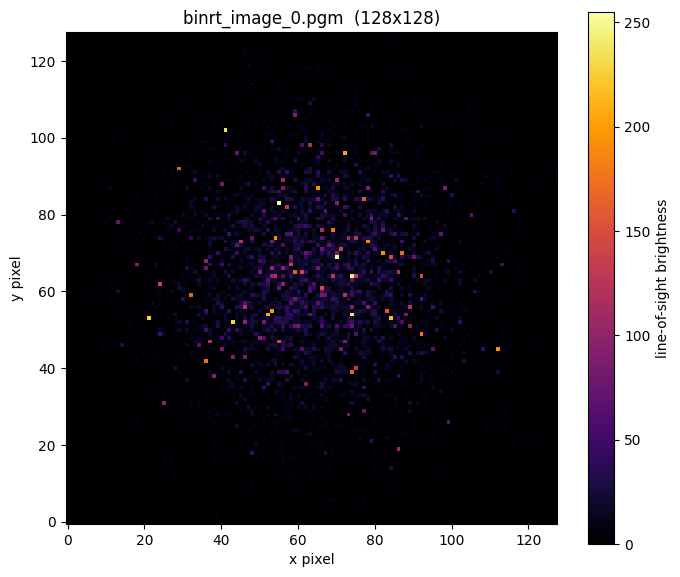

In [9]:
index = 0  # change to view different frames (0 = first, -1 = last)

if use_pgm:
    filepath = files[index]
    w, h, maxval, img = read_pgm_p5(str(filepath))
    title = f"{filepath.name}  ({w}x{h})"
else:
    filepath = files[index]
    img = get_image_h5(filepath, base_dir=".")   # files already absolute
    w, h = img.shape
    title = f"{filepath.name}  ({w}x{h})"

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(img.T if use_pgm else img, origin="lower",
               cmap="inferno", aspect="equal")
ax.set_title(title)
ax.set_xlabel("x pixel"); ax.set_ylabel("y pixel")
plt.colorbar(im, ax=ax, label="line-of-sight brightness")
plt.tight_layout()
plt.show()

### Movie — all frames

Collect every frame, normalize with a common color scale, and export an MP4
movie.  Requires `ffmpeg` on your `$PATH` (Matplotlib uses it as the writer).


In [12]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import Normalize

# ============================================================
# 1.  Load every frame into a list — same logic as the
#     single-frame viewer (PGM or HDF5).
# ============================================================
imgs = []
for i, fp in enumerate(files):
    if use_pgm:
        _, _, _, img = read_pgm_p5(str(fp))
    else:
        img = get_image_h5(fp, base_dir=".")
    imgs.append(img.T if use_pgm else img)

print(f"Loaded {len(imgs)} frames")

# ============================================================
# 2.  Global min / max so the color scale is consistent across
#     all frames.
# ============================================================
flat_imgs = np.concatenate([img.ravel() for img in imgs])
vmin = float(np.percentile(flat_imgs, 1))   # clip bottom 1 %
vmax = float(np.percentile(flat_imgs, 99))  # clip top 1 %
norm = Normalize(vmin=vmin, vmax=vmax)

# ============================================================
# 3.  Build the animation
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(imgs[0], origin="lower", cmap="inferno", norm=norm,
               aspect="equal")
cbar = plt.colorbar(im, ax=ax, label="line-of-sight brightness")
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
title = ax.set_title("")

def animate(frame_idx):
    im.set_data(imgs[frame_idx])
    # extract step number from filename for the title
    stem = files[frame_idx].stem           # e.g. "rt_image_5" or "fld.00005"
    step = re.search(r"(\d+)", stem).group()
    title.set_text(f"step {step}")
    return [im, title]

ani = FuncAnimation(fig, animate, frames=len(imgs), interval=150, blit=True)

# ============================================================
# 4.  Write MP4 to the notebook’s own directory
# ============================================================
out_path = Path("ray_tracer_movie.mp4")   # saved next to this notebook
print(f"Writing {out_path.resolve()} …")
writer = FFMpegWriter(fps=8, bitrate=2000)
ani.save(str(out_path), writer=writer)
print(f"Done → {out_path.resolve()}")

plt.close(fig)


Loaded 41 frames
Writing /home/aaron/Research/Aperture4/problems/ray_tracing/ray_tracer_movie.mp4 …
Done → /home/aaron/Research/Aperture4/problems/ray_tracing/ray_tracer_movie.mp4


### 3D Particle Positions — camera view

Scatter plot of particle $(x,y)$ positions, colored by $z$, from an HDF5
field snapshot.  Uses the same top-down perspective as the ray tracer
camera (observer at $+z$, looking back along $-z$).

Pick a snapshot below; all particles in that file are shown.


In [ ]:
# ============================================================
#  Choose a field HDF5 snapshot to read particle positions from.
#  Particles are stored in fld.*.h5 files (NOT ptc.*.h5 — those
#  are metadata stubs with only step/time).
# ============================================================
h5_files = find_image_h5(h5_dir)   # uses default pattern "fld.*.h5"
if not h5_files:
    raise FileNotFoundError(f"No fld.*.h5 snapshots found in {h5_dir}")

snapshot = h5_files[0]   # change index to select a different snapshot
print(f"Using {snapshot.name}")

# ============================================================
#  Read particle positions (x1, x2, x3) from the snapshot
# ============================================================
with h5py.File(snapshot, "r") as f:
    keys = sorted(f.keys())
    has_x1 = "particles_x1" in f
    has_x2 = "particles_x2" in f
    has_x3 = "particles_x3" in f

    if not (has_x1 and has_x2 and has_x3):
        print("Particle position datasets not found by that name.")
        print(f"Available datasets ({len(keys)} total):")
        for k in keys:
            print(f"  {k}   {f[k].shape if hasattr(f[k], 'shape') else 'scalar'}")
    else:
        x = np.asarray(f["particles_x1"])
        y = np.asarray(f["particles_x2"])
        z = np.asarray(f["particles_x3"])
        print(f"Read {len(x)} particle positions from {snapshot.name}")
        print(f"  x range: [{x.min():.3f}, {x.max():.3f}]")
        print(f"  y range: [{y.min():.3f}, {y.max():.3f}]")
        print(f"  z range: [{z.min():.3f}, {z.max():.3f}]")

        # ============================================================
        #  Plot: top-down (camera) view — (x,y) projection, colored by z
        # ============================================================
        fig, (ax_xyz, ax_xy) = plt.subplots(1, 2, figsize=(14, 6))

        # --- 3D scatter (rotatable) ---
        sc3 = ax_xyz.scatter(x, y, c=z, s=0.5, cmap="inferno", alpha=0.6)
        ax_xyz.set_title("3D particle positions  (color = z)")
        ax_xyz.set_xlabel("x")
        ax_xyz.set_ylabel("y")
        ax_xyz.set_zlabel("z")
        plt.colorbar(sc3, ax=ax_xyz, label="z", shrink=0.6)
        # Set the view to match the camera: look down along -z
        ax_xyz.view_init(elev=90, azim=-90)

        # --- Top-down projection (exactly what the camera sees) ---
        sc2 = ax_xy.scatter(x, y, c=z, s=0.3, cmap="inferno", alpha=0.5,
                            edgecolors="none")
        ax_xy.set_title(f"Particles (camera view)  —  {len(x)} particles")
        ax_xy.set_xlabel("x")
        ax_xy.set_ylabel("y")
        ax_xy.set_aspect("equal")
        plt.colorbar(sc2, ax=ax_xy, label="z (depth)", shrink=0.8)

        plt.tight_layout()
        plt.show()

Using ptc.00000.h5
Particle position datasets not found by that name.
Available datasets: ['step', 'time']
